In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
traffic_df = pd.read_csv(
    "../data/raw/Traffic dataset.csv"
)

traffic_df.head()

,Date,City,Area,Vehicle_Type,Vehicle_Count,Accidents,Traffic_Violations,Avg_Speed_kmph,Congestion_Level
0,2025-01-01,Pune,Hinjewadi,Auto,4396,4,44,41,Low
1,2025-01-02,Thane,Manpada,Truck,6708,6,228,31,Low
2,2025-01-03,Mumbai,Lower Parel,Car,12940,3,98,39,High
3,2025-01-04,Thane,Kasarvadavali,Bus,5062,1,245,44,Low
4,2025-01-05,Nashik,College Road,Bus,13794,3,120,44,High


In [3]:
traffic_df.shape

(1200, 9)

In [4]:
traffic_df.columns

Index(['Date', 'City', 'Area', 'Vehicle_Type', 'Vehicle_Count', 'Accidents',
       'Traffic_Violations', 'Avg_Speed_kmph', 'Congestion_Level'],
      dtype='object')

In [5]:
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                1200 non-null   object
 1   City                1200 non-null   object
 2   Area                1200 non-null   object
 3   Vehicle_Type        1200 non-null   object
 4   Vehicle_Count       1200 non-null   int64 
 5   Accidents           1200 non-null   int64 
 6   Traffic_Violations  1200 non-null   int64 
 7   Avg_Speed_kmph      1200 non-null   int64 
 8   Congestion_Level    1200 non-null   object
dtypes: int64(4), object(5)
memory usage: 84.5+ KB


In [6]:
traffic_df.isnull().sum()

Date                  0
City                  0
Area                  0
Vehicle_Type          0
Vehicle_Count         0
Accidents             0
Traffic_Violations    0
Avg_Speed_kmph        0
Congestion_Level      0
dtype: int64

In [7]:
traffic_df.duplicated().sum()

np.int64(0)

In [8]:
traffic_df.describe()

,Vehicle_Count,Accidents,Traffic_Violations,Avg_Speed_kmph
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,9585.048333,4.010833,171.765000,40.570833
std,3194.484195,2.545476,76.657594,11.804636
min,4008.000000,0.000000,40.000000,20.000000
25%,6758.250000,2.000000,104.750000,30.000000
50%,9892.500000,4.000000,175.000000,41.000000
75%,12237.750000,6.000000,239.000000,51.000000
max,14993.000000,8.000000,300.000000,60.000000


In [9]:
traffic = traffic_df.copy()

In [10]:
traffic["Date"] = pd.to_datetime(traffic["Date"])

In [11]:
traffic["Date"].dtype

dtype('<M8[ns]')

In [12]:
print("Cities:")
print(traffic["City"].unique())

print("\nAreas:")
print(traffic["Area"].unique())

print("\nVehicle Types:")
print(traffic["Vehicle_Type"].unique())

print("\nCongestion Levels:")
print(traffic["Congestion_Level"].unique())

Cities:
['Pune' 'Thane' 'Mumbai' 'Nashik' 'Nagpur']

Areas:
['Hinjewadi' 'Manpada' 'Lower Parel' 'Kasarvadavali' 'College Road'
 'Shivaji Nagar' 'Trimurti Nagar' 'Mumbai Naka' 'Dharampeth'
 'Pratap Nagar' 'Ghodbunder' 'Gangapur Road' 'Dadar' 'Indira Nagar'
 'Viman Nagar' 'Bandra' 'Kothrud' 'Sadar' 'Majiwada' 'Sitabuldi' 'Andheri'
 'Malad' 'Wagle Estate' 'Panchavati' 'Wakad']

Vehicle Types:
['Auto' 'Truck' 'Car' 'Bus' 'Bike']

Congestion Levels:
['Low' 'High' 'Medium']


In [13]:
traffic.duplicated().sum()

np.int64(0)

In [14]:
print("Start Date:", traffic["Date"].min())
print("End Date:", traffic["Date"].max())

Start Date: 2025-01-01 00:00:00
End Date: 2025-12-31 00:00:00


In [15]:
numeric_cols = [
    "Vehicle_Count",
    "Accidents",
    "Traffic_Violations",
    "Avg_Speed_kmph"
]

traffic[numeric_cols].describe()

,Vehicle_Count,Accidents,Traffic_Violations,Avg_Speed_kmph
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,9585.048333,4.010833,171.765000,40.570833
std,3194.484195,2.545476,76.657594,11.804636
min,4008.000000,0.000000,40.000000,20.000000
25%,6758.250000,2.000000,104.750000,30.000000
50%,9892.500000,4.000000,175.000000,41.000000
75%,12237.750000,6.000000,239.000000,51.000000
max,14993.000000,8.000000,300.000000,60.000000


In [16]:
city_traffic = (
    traffic.groupby("City")["Vehicle_Count"]
    .sum()
    .sort_values(ascending=False)
)

city_traffic

City
Nashik    2535269
Thane     2352663
Pune      2258406
Mumbai    2198176
Nagpur    2157544
Name: Vehicle_Count, dtype: int64

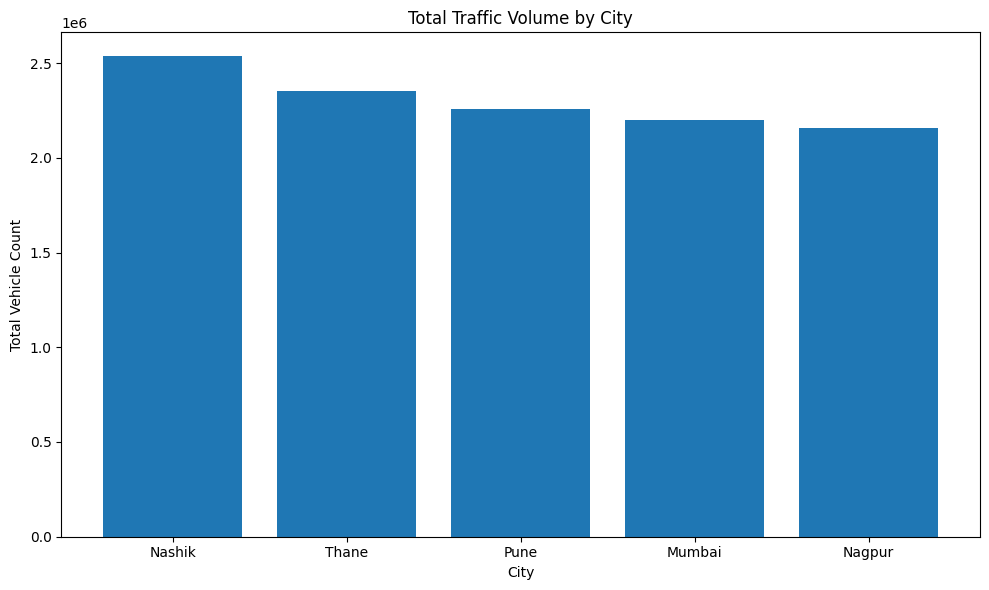

In [20]:
plt.figure(figsize=(10, 6))

plt.bar(city_traffic.index, city_traffic.values)

plt.title("Total Traffic Volume by City")
plt.xlabel("City")
plt.ylabel("Total Vehicle Count")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/total_traffic_volume_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [21]:
vehicle_traffic = (
    traffic.groupby("Vehicle_Type")["Vehicle_Count"]
    .sum()
    .sort_values(ascending=False)
)

vehicle_traffic

Vehicle_Type
Car      2450377
Bus      2359389
Bike     2355337
Auto     2177541
Truck    2159414
Name: Vehicle_Count, dtype: int64

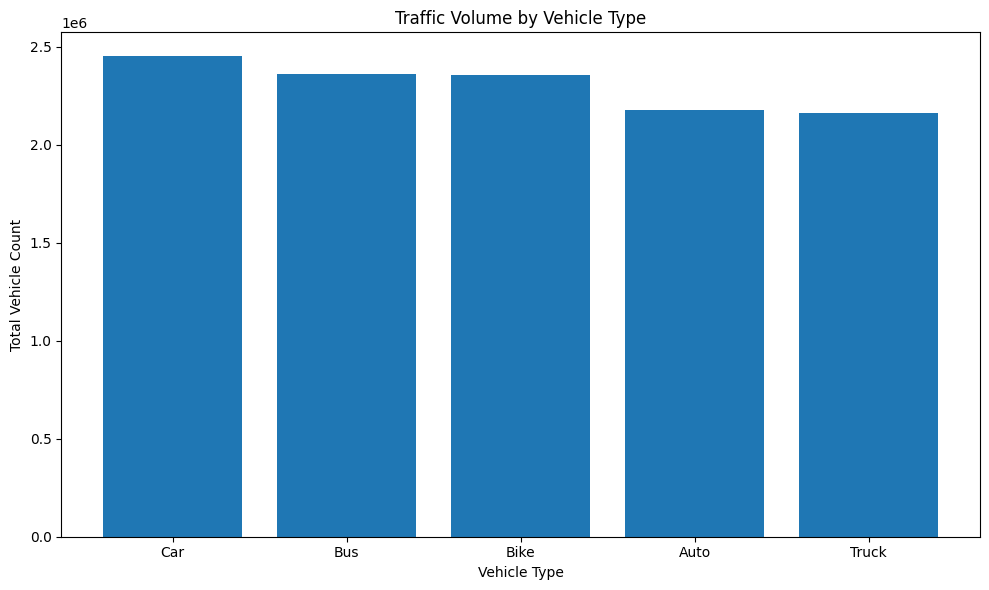

In [22]:
plt.figure(figsize=(10, 6))

plt.bar(vehicle_traffic.index, vehicle_traffic.values)

plt.title("Traffic Volume by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Vehicle Count")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/traffic_volume_by_vehicle_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [23]:
congestion_counts = (
    traffic["Congestion_Level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

congestion_counts

Congestion_Level
Low       333
Medium    418
High      449
Name: count, dtype: int64

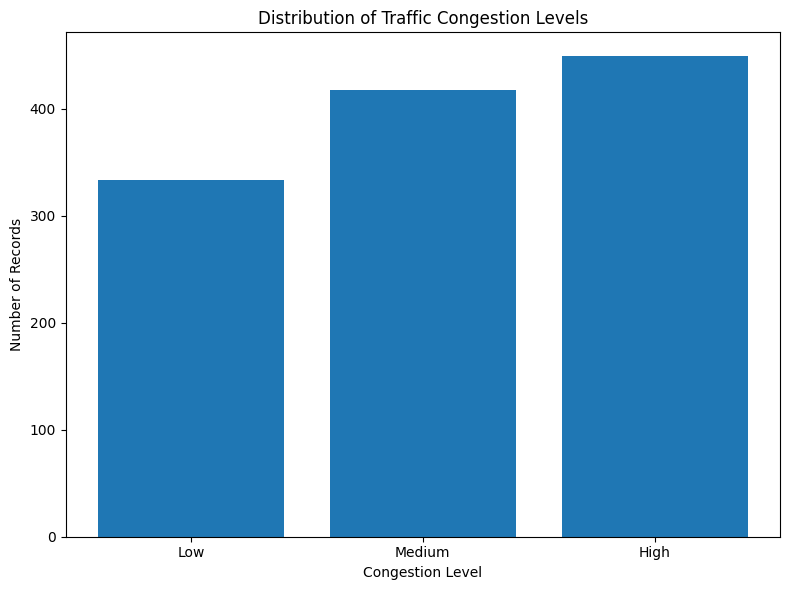

In [24]:
plt.figure(figsize=(8, 6))

plt.bar(
    congestion_counts.index,
    congestion_counts.values
)

plt.title("Distribution of Traffic Congestion Levels")
plt.xlabel("Congestion Level")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    "../visualizations/congestion_level_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [25]:
congestion_traffic = (
    traffic.groupby("Congestion_Level")["Vehicle_Count"]
    .mean()
    .reindex(["Low", "Medium", "High"])
)

congestion_traffic

Congestion_Level
Low        5550.108108
Medium     9122.461722
High      13008.202673
Name: Vehicle_Count, dtype: float64

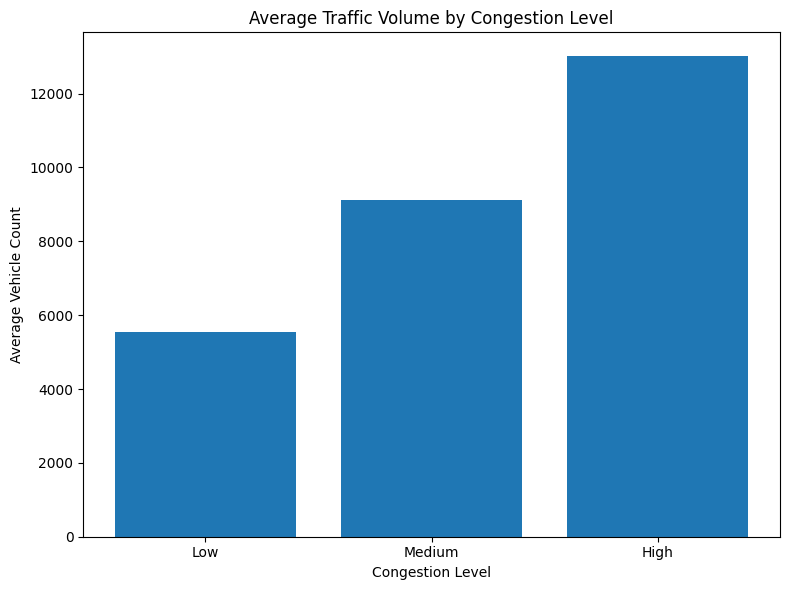

In [26]:
plt.figure(figsize=(8, 6))

plt.bar(
    congestion_traffic.index,
    congestion_traffic.values
)

plt.title("Average Traffic Volume by Congestion Level")
plt.xlabel("Congestion Level")
plt.ylabel("Average Vehicle Count")

plt.tight_layout()

plt.savefig(
    "../visualizations/average_traffic_by_congestion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [27]:
congestion_speed = (
    traffic.groupby("Congestion_Level")["Avg_Speed_kmph"]
    .mean()
    .reindex(["Low", "Medium", "High"])
)

congestion_speed

Congestion_Level
Low       41.456456
Medium    39.547847
High      40.866370
Name: Avg_Speed_kmph, dtype: float64

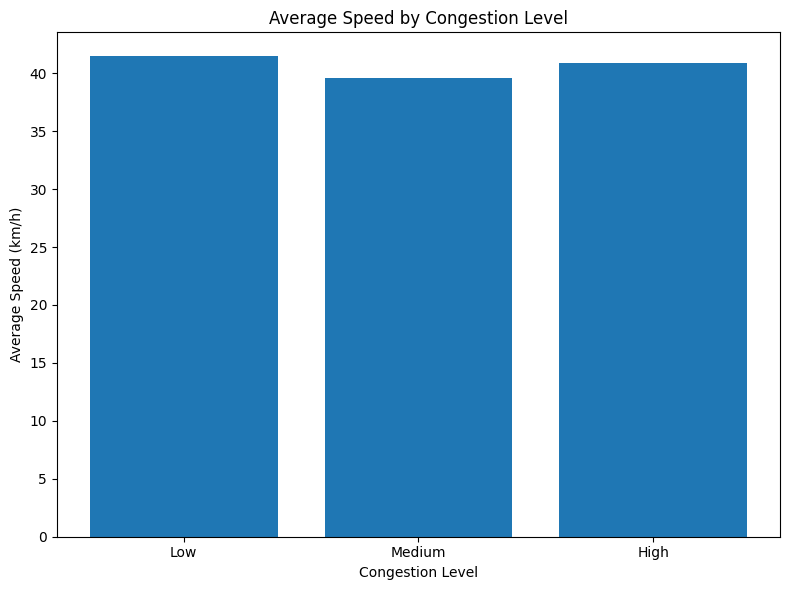

In [28]:
plt.figure(figsize=(8, 6))

plt.bar(
    congestion_speed.index,
    congestion_speed.values
)

plt.title("Average Speed by Congestion Level")
plt.xlabel("Congestion Level")
plt.ylabel("Average Speed (km/h)")

plt.tight_layout()

plt.savefig(
    "../visualizations/average_speed_by_congestion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [29]:
area_traffic = (
    traffic.groupby("Area")["Vehicle_Count"]
    .sum()
    .sort_values(ascending=False)
)

area_traffic

Area
College Road      586862
Mumbai Naka       549659
Kasarvadavali     538604
Shivaji Nagar     521060
Manpada           515376
Indira Nagar      507019
Sitabuldi         496212
Bandra            496028
Ghodbunder        487636
Malad             485860
Gangapur Road     483226
Sadar             472865
Hinjewadi         463546
Wagle Estate      451009
Wakad             449502
Andheri           442160
Kothrud           422004
Trimurti Nagar    418404
Panchavati        408503
Viman Nagar       402294
Dadar             390754
Pratap Nagar      389536
Lower Parel       383374
Dharampeth        380527
Majiwada          360038
Name: Vehicle_Count, dtype: int64

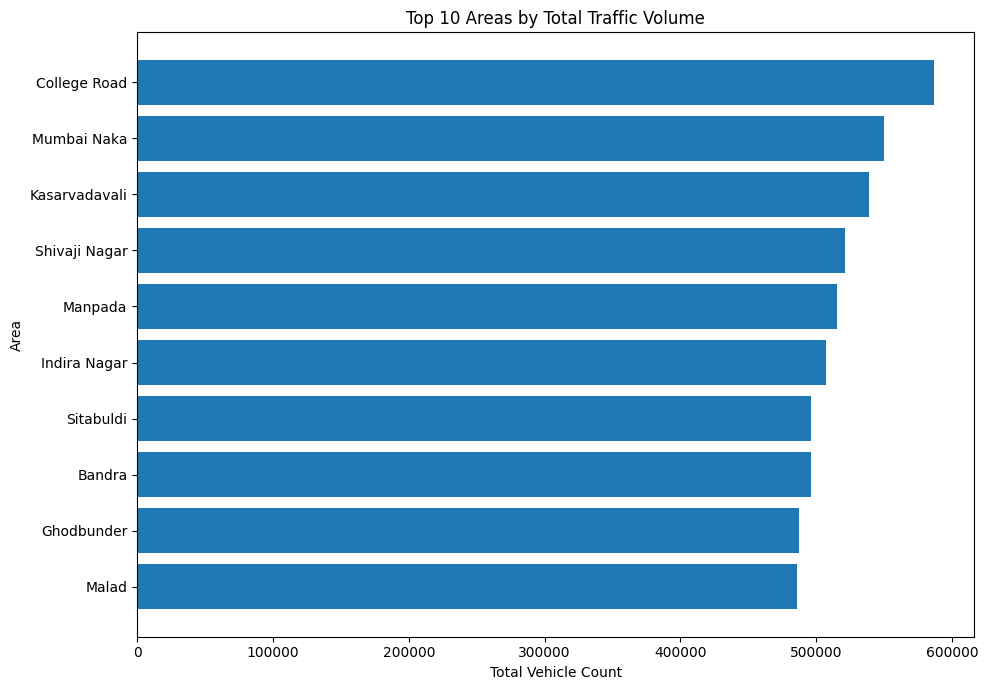

In [30]:
top_10_areas = area_traffic.head(10)

plt.figure(figsize=(10, 7))

plt.barh(
    top_10_areas.index[::-1],
    top_10_areas.values[::-1]
)

plt.title("Top 10 Areas by Total Traffic Volume")
plt.xlabel("Total Vehicle Count")
plt.ylabel("Area")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_10_areas_by_traffic_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [31]:
congestion_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

traffic["Congestion_Score"] = (
    traffic["Congestion_Level"]
    .map(congestion_mapping)
)

In [32]:
area_congestion = (
    traffic.groupby("Area")["Congestion_Score"]
    .mean()
    .sort_values(ascending=False)
)

area_congestion.head(10)

Area
Kothrud          2.350000
Viman Nagar      2.256410
Gangapur Road    2.229167
Sitabuldi        2.220000
Ghodbunder       2.200000
Wagle Estate     2.181818
Lower Parel      2.179487
Mumbai Naka      2.166667
Sadar            2.142857
Kasarvadavali    2.129630
Name: Congestion_Score, dtype: float64

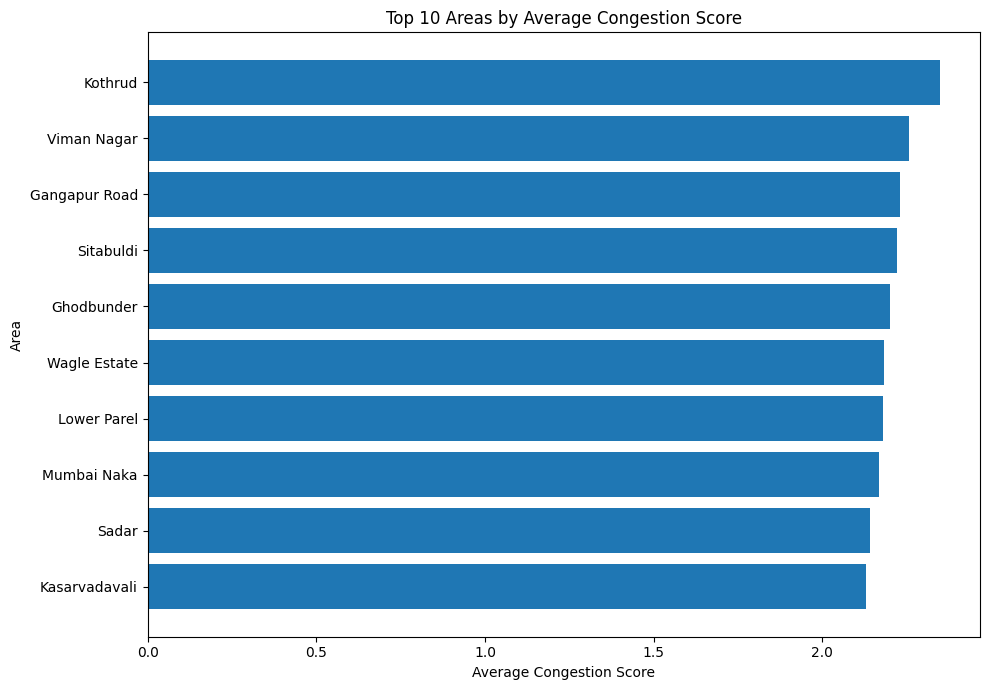

In [33]:
top_10_congestion = area_congestion.head(10)

plt.figure(figsize=(10, 7))

plt.barh(
    top_10_congestion.index[::-1],
    top_10_congestion.values[::-1]
)

plt.title("Top 10 Areas by Average Congestion Score")
plt.xlabel("Average Congestion Score")
plt.ylabel("Area")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_10_areas_by_congestion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [34]:
area_traffic.head(10)

Area
College Road     586862
Mumbai Naka      549659
Kasarvadavali    538604
Shivaji Nagar    521060
Manpada          515376
Indira Nagar     507019
Sitabuldi        496212
Bandra           496028
Ghodbunder       487636
Malad            485860
Name: Vehicle_Count, dtype: int64

In [35]:
city_accidents = (
    traffic.groupby("City")["Accidents"]
    .sum()
    .sort_values(ascending=False)
)

city_accidents

City
Nashik    1084
Thane     1027
Nagpur     925
Pune       892
Mumbai     885
Name: Accidents, dtype: int64

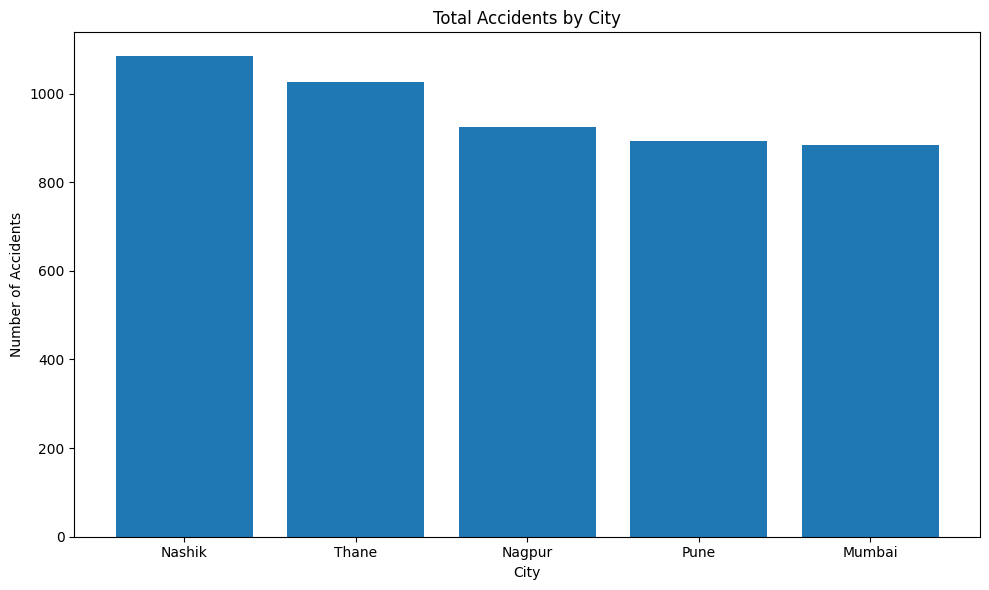

In [36]:
plt.figure(figsize=(10, 6))

plt.bar(
    city_accidents.index,
    city_accidents.values
)

plt.title("Total Accidents by City")
plt.xlabel("City")
plt.ylabel("Number of Accidents")

plt.tight_layout()

plt.savefig(
    "../visualizations/total_accidents_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [37]:
city_violations = (
    traffic.groupby("City")["Traffic_Violations"]
    .sum()
    .sort_values(ascending=False)
)

city_violations

City
Nashik    43743
Mumbai    42699
Thane     40892
Nagpur    40181
Pune      38603
Name: Traffic_Violations, dtype: int64

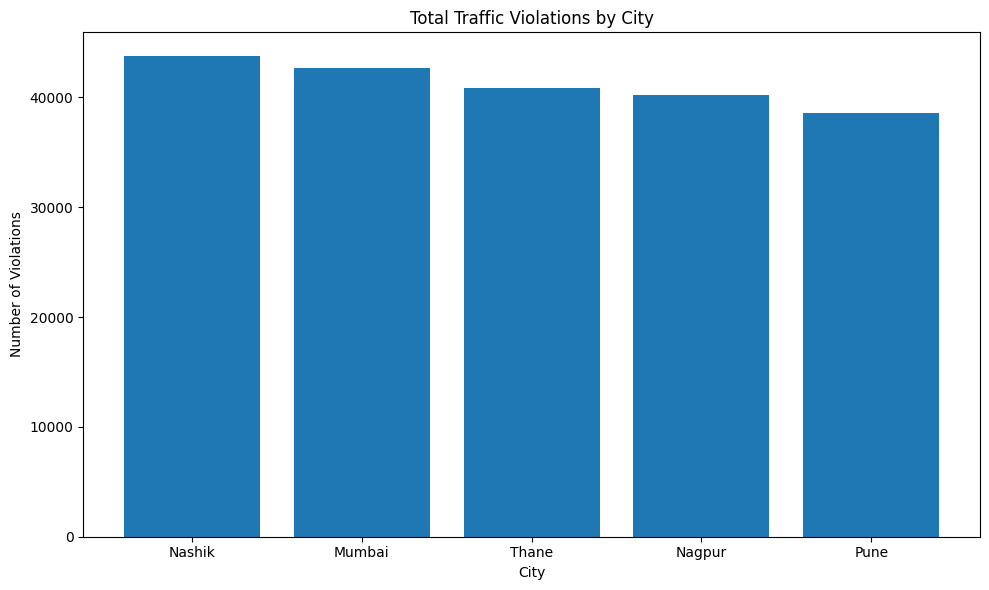

In [38]:
plt.figure(figsize=(10, 6))

plt.bar(
    city_violations.index,
    city_violations.values
)

plt.title("Total Traffic Violations by City")
plt.xlabel("City")
plt.ylabel("Number of Violations")

plt.tight_layout()

plt.savefig(
    "../visualizations/total_traffic_violations_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [39]:
print("City-wise accidents:")
print(city_accidents)

print("\nCity-wise traffic violations:")
print(city_violations)

City-wise accidents:
City
Nashik    1084
Thane     1027
Nagpur     925
Pune       892
Mumbai     885
Name: Accidents, dtype: int64

City-wise traffic violations:
City
Nashik    43743
Mumbai    42699
Thane     40892
Nagpur    40181
Pune      38603
Name: Traffic_Violations, dtype: int64


In [40]:
city_accidents = (
    traffic.groupby("City")["Accidents"]
    .sum()
    .sort_values(ascending=False)
)

print(city_accidents)

City
Nashik    1084
Thane     1027
Nagpur     925
Pune       892
Mumbai     885
Name: Accidents, dtype: int64


In [41]:
city_violations = (
    traffic.groupby("City")["Traffic_Violations"]
    .sum()
    .sort_values(ascending=False)
)

print(city_violations)

City
Nashik    43743
Mumbai    42699
Thane     40892
Nagpur    40181
Pune      38603
Name: Traffic_Violations, dtype: int64


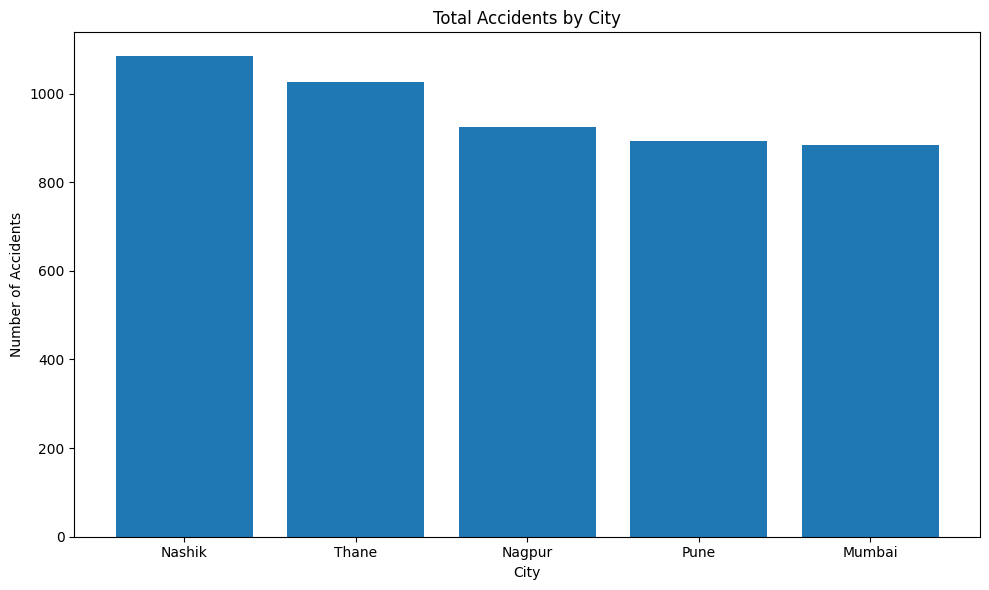

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(city_accidents.index, city_accidents.values)

plt.title("Total Accidents by City")
plt.xlabel("City")
plt.ylabel("Number of Accidents")

plt.tight_layout()
plt.savefig(
    "../visualizations/total_accidents_by_city.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

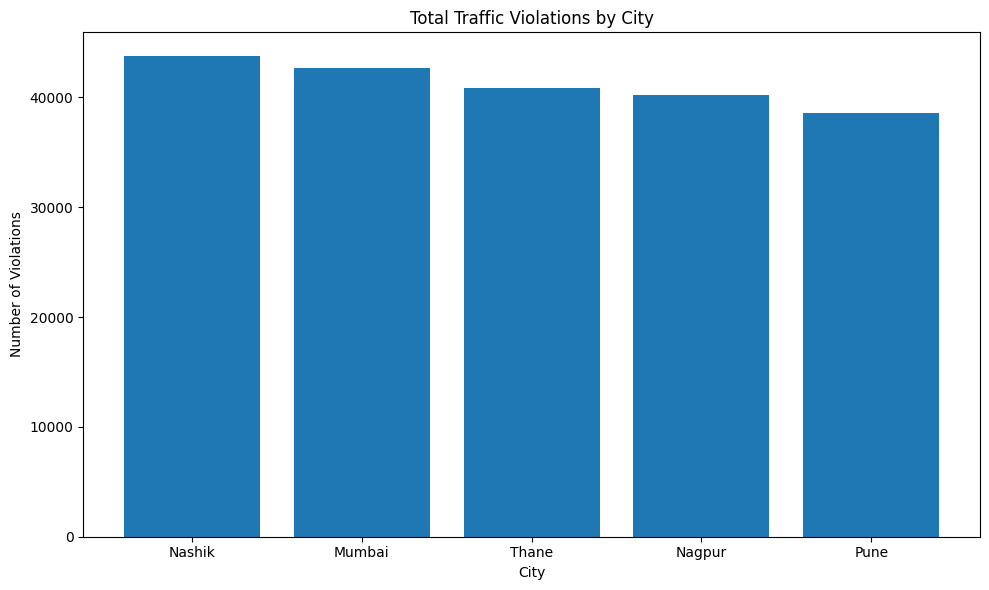

In [43]:
plt.figure(figsize=(10, 6))

plt.bar(city_violations.index, city_violations.values)

plt.title("Total Traffic Violations by City")
plt.xlabel("City")
plt.ylabel("Number of Violations")

plt.tight_layout()
plt.savefig(
    "../visualizations/total_traffic_violations_by_city.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

## 4. Chicago Public Transport Analysis

In [44]:
chicago_df = pd.read_csv(
    "../data/raw/Chicago_Ridership.csv"
)

chicago_df.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,01/01/2001,U,"297,192","126,455","423,647"
1,01/02/2001,W,"780,827","501,952","1,282,779"
2,01/03/2001,W,"824,923","536,432","1,361,355"
3,01/04/2001,W,"870,021","550,011","1,420,032"
4,01/05/2001,W,"890,426","557,917","1,448,343"


In [45]:
chicago_df.shape

(9312, 5)

In [46]:
chicago_df.columns

Index(['service_date', 'day_type', 'bus', 'rail_boardings', 'total_rides'], dtype='object')

In [47]:
chicago_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9312 entries, 0 to 9311
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   service_date    9312 non-null   object
 1   day_type        9312 non-null   object
 2   bus             9312 non-null   object
 3   rail_boardings  9312 non-null   object
 4   total_rides     9312 non-null   object
dtypes: object(5)
memory usage: 363.9+ KB


In [48]:
chicago_df.isnull().sum()

service_date      0
day_type          0
bus               0
rail_boardings    0
total_rides       0
dtype: int64

In [49]:
chicago_df.duplicated().sum()

np.int64(0)

In [50]:
chicago_df.describe()

,service_date,day_type,bus,rail_boardings,total_rides
count,9312,9312,9312,9312,9312
unique,9312,3,9265,9252,9276
top,05/22/2026,W,"488,902","602,096","1,672,291"
freq,1,6504,3,2,2


In [51]:
chicago = chicago_df.copy()

In [52]:
chicago["service_date"] = pd.to_datetime(
    chicago["service_date"],
    format="%m/%d/%Y"
)

In [53]:
ridership_cols = [
    "bus",
    "rail_boardings",
    "total_rides"
]

for col in ridership_cols:
    chicago[col] = (
        chicago[col]
        .str.replace(",", "", regex=False)
        .astype(int)
    )

In [54]:
chicago.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9312 entries, 0 to 9311
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   service_date    9312 non-null   datetime64[ns]
 1   day_type        9312 non-null   object        
 2   bus             9312 non-null   int64         
 3   rail_boardings  9312 non-null   int64         
 4   total_rides     9312 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 363.9+ KB


In [55]:
print("Start Date:", chicago["service_date"].min())
print("End Date:", chicago["service_date"].max())

Start Date: 2001-01-01 00:00:00
End Date: 2026-06-30 00:00:00


In [56]:
chicago["day_type"].value_counts()

day_type
W    6504
U    1482
A    1326
Name: count, dtype: int64

In [57]:
print("Total Bus Ridership:", chicago["bus"].sum())
print("Total Rail Ridership:", chicago["rail_boardings"].sum())
print("Total Ridership:", chicago["total_rides"].sum())

Total Bus Ridership: 6540465889
Total Rail Ridership: 4689196055
Total Ridership: 11229661944


In [58]:
chicago[
    ["bus", "rail_boardings", "total_rides"]
].describe()

,bus,rail_boardings,total_rides
count,9.312000e+03,9.312000e+03,9.312000e+03
mean,7.023696e+05,5.035649e+05,1.205934e+06
std,2.670212e+05,2.057457e+05,4.599578e+05
min,8.078300e+04,2.354400e+04,1.100470e+05
25%,4.615280e+05,3.264688e+05,7.982322e+05
50%,7.328475e+05,5.582580e+05,1.331625e+06
75%,9.525740e+05,6.835025e+05,1.623327e+06
max,1.211992e+06,1.146516e+06,2.049519e+06


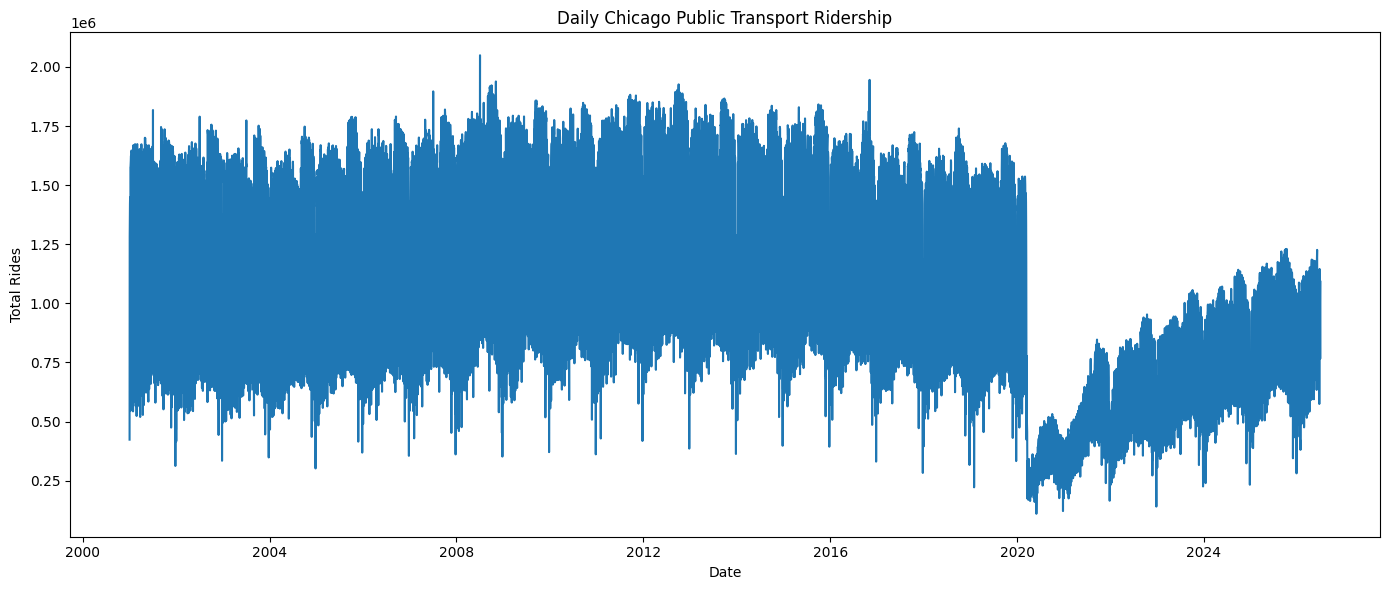

In [59]:
plt.figure(figsize=(14, 6))

plt.plot(
    chicago["service_date"],
    chicago["total_rides"]
)

plt.title("Daily Chicago Public Transport Ridership")
plt.xlabel("Date")
plt.ylabel("Total Rides")

plt.tight_layout()

plt.savefig(
    "../visualizations/daily_total_ridership.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [60]:
chicago["day_type"].value_counts()

day_type
W    6504
U    1482
A    1326
Name: count, dtype: int64

In [61]:
bus_total = chicago["bus"].sum()
rail_total = chicago["rail_boardings"].sum()

print("Total Bus Ridership:", bus_total)
print("Total Rail Ridership:", rail_total)

Total Bus Ridership: 6540465889
Total Rail Ridership: 4689196055


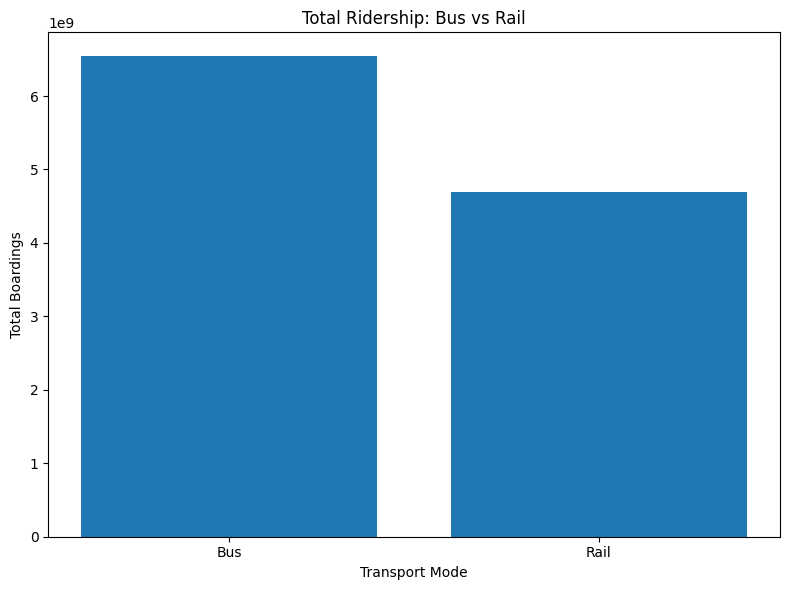

In [62]:
plt.figure(figsize=(8, 6))

plt.bar(
    ["Bus", "Rail"],
    [bus_total, rail_total]
)

plt.title("Total Ridership: Bus vs Rail")
plt.xlabel("Transport Mode")
plt.ylabel("Total Boardings")

plt.tight_layout()

plt.savefig(
    "../visualizations/total_ridership_bus_vs_rail.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

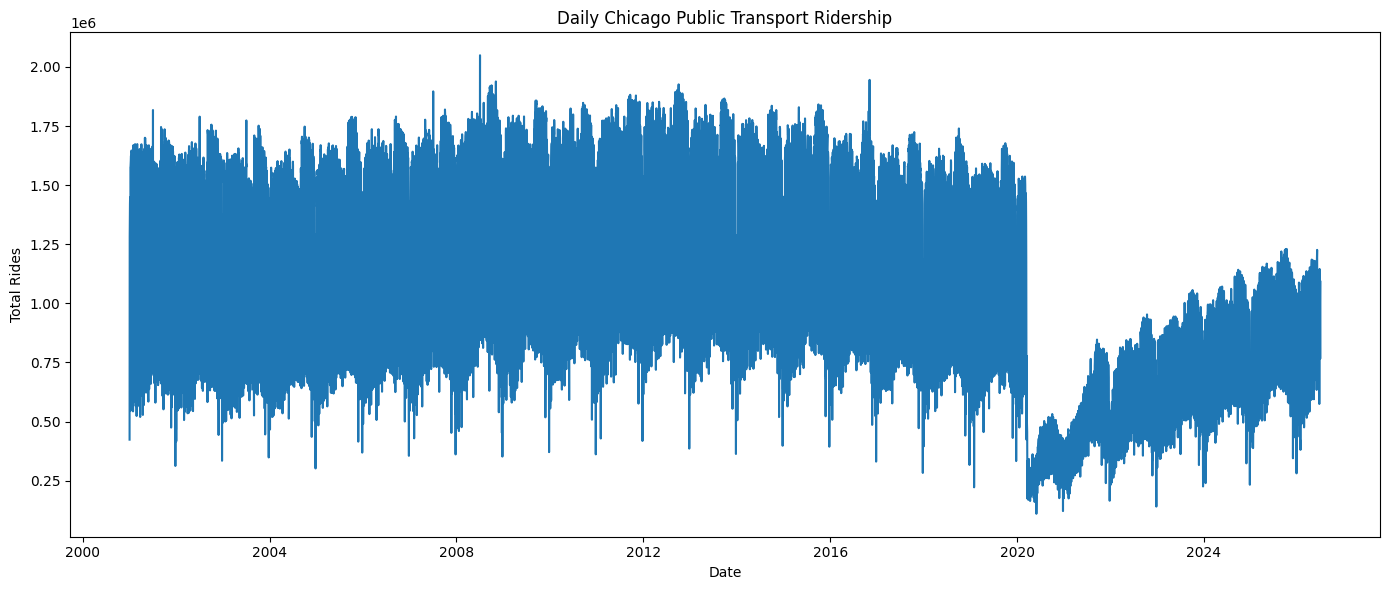

In [63]:
plt.figure(figsize=(14, 6))

plt.plot(
    chicago["service_date"],
    chicago["total_rides"]
)

plt.title("Daily Chicago Public Transport Ridership")
plt.xlabel("Date")
plt.ylabel("Total Rides")

plt.tight_layout()

plt.savefig(
    "../visualizations/daily_total_ridership.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [64]:
day_type_map = {
    "W": "Weekday",
    "A": "Saturday",
    "U": "Sunday/Holiday"
}

chicago["Day_Type_Label"] = chicago["day_type"].map(day_type_map)

In [ ]:
bus_total = chicago["bus"].sum()
rail_total = chicago["rail_boardings"].sum()

print("Total Bus Ridership:", bus_total)
print("Total Rail Ridership:", rail_total)

Total Bus Ridership: 6540465889
Total Rail Ridership: 4689196055


In [65]:
day_ridership = (
    chicago.groupby("Day_Type_Label")["total_rides"]
    .mean()
    .reindex(["Weekday", "Saturday", "Sunday/Holiday"])
)

day_ridership

Day_Type_Label
Weekday           1.403891e+06
Saturday          8.806226e+05
Sunday/Holiday    6.282366e+05
Name: total_rides, dtype: float64

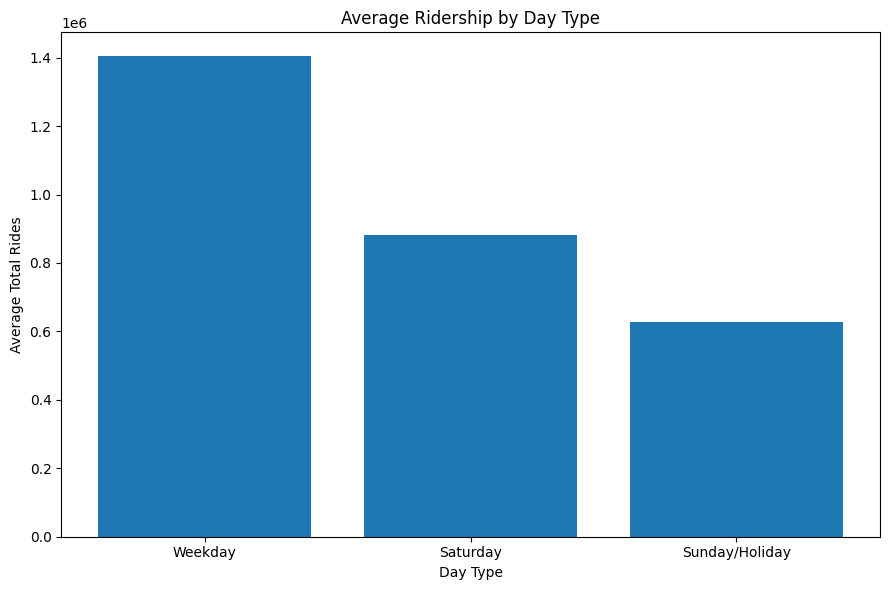

In [66]:
plt.figure(figsize=(9, 6))

plt.bar(
    day_ridership.index,
    day_ridership.values
)

plt.title("Average Ridership by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Average Total Rides")

plt.tight_layout()

plt.savefig(
    "../visualizations/average_ridership_by_day_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [67]:
chicago["Month"] = chicago["service_date"].dt.to_period("M")

In [68]:
monthly_ridership = (
    chicago.groupby("Month")["total_rides"]
    .mean()
)

In [69]:
monthly_ridership.index = monthly_ridership.index.to_timestamp()

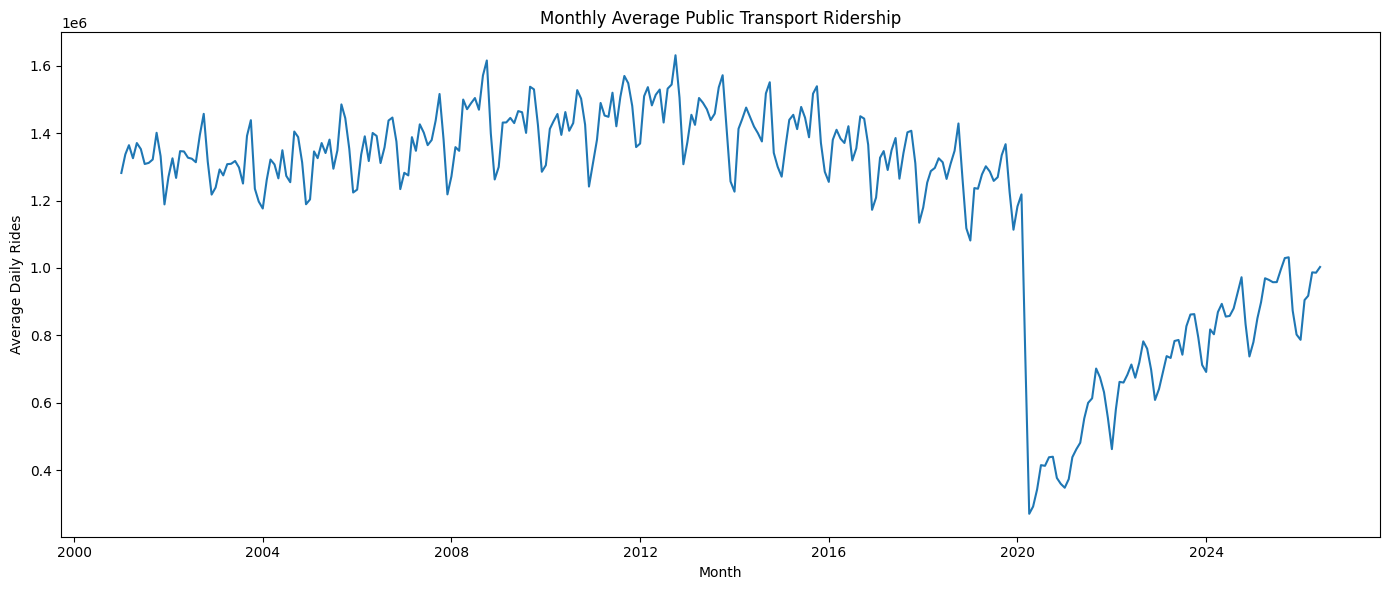

In [70]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_ridership.index,
    monthly_ridership.values
)

plt.title("Monthly Average Public Transport Ridership")
plt.xlabel("Month")
plt.ylabel("Average Daily Rides")

plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_average_ridership.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [71]:
traffic.to_csv(
    "../data/processed/traffic_cleaned.csv",
    index=False
)

In [72]:
chicago.to_csv(
    "../data/processed/chicago_ridership_cleaned.csv",
    index=False
)

## 5. SQL Analytics

In [73]:
import sqlite3
conn = sqlite3.connect("../urban_mobility.db")

In [74]:
traffic.to_sql(
    "traffic",
    conn,
    if_exists="replace",
    index=False
)

chicago.to_sql(
    "public_transport",
    conn,
    if_exists="replace",
    index=False
)

InterfaceError: Error binding parameter 6 - probably unsupported type.

In [75]:
# Remove the Period-type column before sending data to SQLite
chicago_sql = chicago.drop(columns=["Month"]).copy()

In [76]:
traffic.to_sql(
    "traffic",
    conn,
    if_exists="replace",
    index=False
)

chicago_sql.to_sql(
    "public_transport",
    conn,
    if_exists="replace",
    index=False
)

9312

In [77]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    conn
)

tables

,name
0,traffic
1,public_transport


In [78]:
query = """
SELECT
    City,
    SUM(Vehicle_Count) AS total_vehicle_count
FROM traffic
GROUP BY City
ORDER BY total_vehicle_count DESC;
"""

traffic_by_city_sql = pd.read_sql_query(query, conn)
traffic_by_city_sql

,City,total_vehicle_count
0,Nashik,2535269
1,Thane,2352663
2,Pune,2258406
3,Mumbai,2198176
4,Nagpur,2157544


In [79]:
query = """
SELECT
    Congestion_Level,
    ROUND(AVG(Avg_Speed_kmph), 2) AS average_speed
FROM traffic
GROUP BY Congestion_Level
ORDER BY
    CASE Congestion_Level
        WHEN 'Low' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'High' THEN 3
    END;
"""

speed_by_congestion_sql = pd.read_sql_query(query, conn)
speed_by_congestion_sql

,Congestion_Level,average_speed
0,Low,41.46
1,Medium,39.55
2,High,40.87


In [80]:
query = """
SELECT
    Area,
    SUM(Vehicle_Count) AS total_vehicle_count
FROM traffic
GROUP BY Area
ORDER BY total_vehicle_count DESC
LIMIT 10;
"""

top_areas_sql = pd.read_sql_query(query, conn)
top_areas_sql

,Area,total_vehicle_count
0,College Road,586862
1,Mumbai Naka,549659
2,Kasarvadavali,538604
3,Shivaji Nagar,521060
4,Manpada,515376
5,Indira Nagar,507019
6,Sitabuldi,496212
7,Bandra,496028
8,Ghodbunder,487636
9,Malad,485860


In [81]:
query = """
SELECT
    City,
    SUM(Accidents) AS total_accidents,
    SUM(Traffic_Violations) AS total_violations
FROM traffic
GROUP BY City
ORDER BY total_accidents DESC;
"""

safety_by_city_sql = pd.read_sql_query(query, conn)
safety_by_city_sql

,City,total_accidents,total_violations
0,Nashik,1084,43743
1,Thane,1027,40892
2,Nagpur,925,40181
3,Pune,892,38603
4,Mumbai,885,42699


In [82]:
query = """
SELECT
    SUM(bus) AS total_bus_ridership,
    SUM(rail_boardings) AS total_rail_ridership,
    SUM(total_rides) AS total_ridership
FROM public_transport;
"""

ridership_summary_sql = pd.read_sql_query(query, conn)
ridership_summary_sql

,total_bus_ridership,total_rail_ridership,total_ridership
0,6540465889,4689196055,11229661944


In [83]:
query = """
SELECT
    day_type,
    COUNT(*) AS number_of_days,
    ROUND(AVG(total_rides), 2) AS average_daily_ridership
FROM public_transport
GROUP BY day_type
ORDER BY average_daily_ridership DESC;
"""

day_type_sql = pd.read_sql_query(query, conn)
day_type_sql

,day_type,number_of_days,average_daily_ridership
0,W,6504,1403891.42
1,A,1326,880622.59
2,U,1482,628236.59


In [84]:
query = """
SELECT
    strftime('%Y', service_date) AS year,
    SUM(bus) AS bus_ridership,
    SUM(rail_boardings) AS rail_ridership,
    SUM(total_rides) AS total_ridership
FROM public_transport
GROUP BY year
ORDER BY year;
"""

yearly_ridership_sql = pd.read_sql_query(query, conn)
yearly_ridership_sql

,year,bus_ridership,rail_ridership,total_ridership
0,2001,301712869,181692888,483405757
1,2002,303301459,180399629,483701088
2,2003,291805659,181135096,472940755
3,2004,294030716,178716468,472747184
4,2005,303244172,186759525,490003697
5,2006,298433226,195169313,493602539
6,2007,309271308,190273414,499544722
7,2008,328199217,198137253,526336470
8,2009,318672787,202569040,521241827
9,2010,306023984,210849074,516873058


In [85]:
traffic.to_csv(
    "../data/processed/traffic_powerbi.csv",
    index=False
)

In [86]:
chicago.to_csv(
    "../data/processed/public_transport_powerbi.csv",
    index=False
)

In [87]:
traffic_by_city_sql.to_csv(
    "../data/processed/sql_traffic_by_city.csv",
    index=False
)

speed_by_congestion_sql.to_csv(
    "../data/processed/sql_speed_by_congestion.csv",
    index=False
)

top_areas_sql.to_csv(
    "../data/processed/sql_top_areas.csv",
    index=False
)

safety_by_city_sql.to_csv(
    "../data/processed/sql_safety_by_city.csv",
    index=False
)

ridership_summary_sql.to_csv(
    "../data/processed/sql_ridership_summary.csv",
    index=False
)

day_type_sql.to_csv(
    "../data/processed/sql_day_type_ridership.csv",
    index=False
)

yearly_ridership_sql.to_csv(
    "../data/processed/sql_yearly_ridership.csv",
    index=False
)